<a href="https://colab.research.google.com/github/jhamidi1/Data201-Spring/blob/main/DATA201_Week5_Assignment_Iris_Resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
print("Number of observations:", iris.shape[0])

Number of observations: 150


In [14]:
print("Column names:")
print(iris.columns)

Column names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [15]:
print(iris["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Part 1 --- Bootstrap Resampling

## Task 1 --- Basic Statistics


In [16]:
sepal_length = iris["sepal_length"]

print("Mean:", sepal_length.mean())
print("Median:", sepal_length.median())
print("Standard Deviation:", sepal_length.std())

Mean: 5.843333333333334
Median: 5.8
Standard Deviation: 0.8280661279778629


## Task 2 --- Bootstrap the Mean


In [17]:
bootstrap_means = []

for i in range(5000):
    sample = iris.sample(n=150, replace=True)
    mean_value = sample["sepal_length"].mean()
    bootstrap_means.append(mean_value)

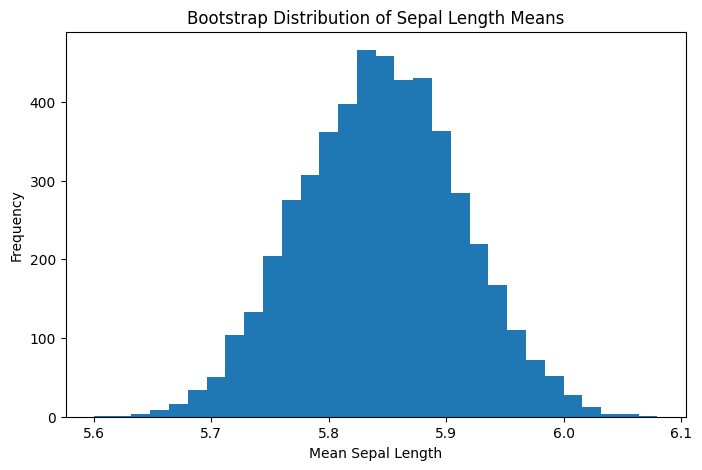

In [18]:
plt.figure(figsize=(8,5))

plt.hist(bootstrap_means, bins=30)

plt.title("Bootstrap Distribution of Sepal Length Means")
plt.xlabel("Mean Sepal Length")
plt.ylabel("Frequency")

plt.show()

## Task 3 --- Confidence Interval


In [19]:
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

bootstrap_mean = np.mean(bootstrap_means)

print("Bootstrap Mean:", bootstrap_mean)
print("95% Confidence Interval:")
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Bootstrap Mean: 5.844237333333334
95% Confidence Interval:
Lower Bound: 5.714
Upper Bound: 5.97735


Why is it mathematically necessary to sample with replacement in bootstrap resampling?

Bootstrap resampling usees sampling with replacement because it allows for each resample to act like a new random sample from the population, and some observations may come multiple times while others may not appear at all. This creates variability between samples. Without replacement, every resample would have nearly the same data and would not properly estimate sampling variability.


# Part 2 --- Jackknife Resampling


## Task 4 --- Jackknife the Mean


In [20]:
jackknife_means = []

n = len(iris)

for i in range(n):
    jackknife_sample = iris.drop(index=i)
    mean_value = jackknife_sample["sepal_length"].mean()
    jackknife_means.append(mean_value)

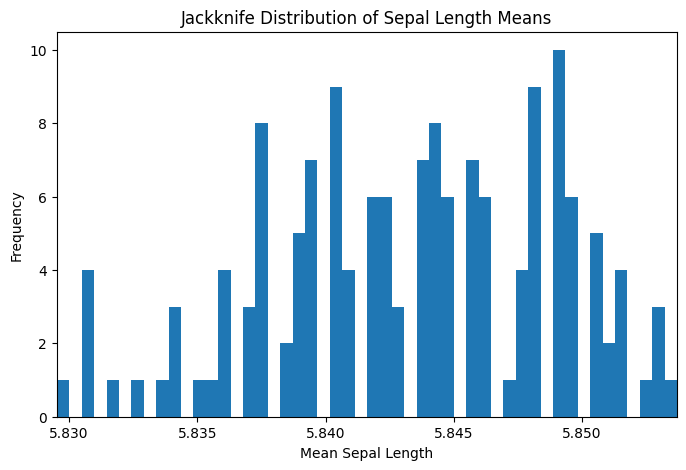

In [21]:
plt.figure(figsize=(8,5))

plt.hist(jackknife_means, bins=50)

plt.title("Jackknife Distribution of Sepal Length Means")
plt.xlabel("Mean Sepal Length")
plt.ylabel("Frequency")

plt.xlim(min(jackknife_means), max(jackknife_means))

plt.show()

If the dataset contains n observations, exactly how many jackknife samples are created?
If the dataset contains n observations, exactly n jackknife samples are created because one observation is removed at a time from the dataset.


# Part 3 --- Permutation Test


## Task 5 --- Observed Statistic


In [22]:
versicolor = iris[iris["species"] == "versicolor"]["sepal_length"]
virginica = iris[iris["species"] == "virginica"]["sepal_length"]

observed_difference = versicolor.mean() - virginica.mean()

print("Observed Difference:", observed_difference)

Observed Difference: -0.6519999999999984


## Task 6 --- Permutation Simulation


In [24]:
combined = pd.concat([versicolor, virginica])
permutation_differences = []

for i in range(1000):
    shuffled = np.random.permutation(combined)
    group1 = shuffled[:len(versicolor)]
    group2 = shuffled[len(versicolor):]
    diff = np.mean(group1) - np.mean(group2)
    permutation_differences.append(diff)

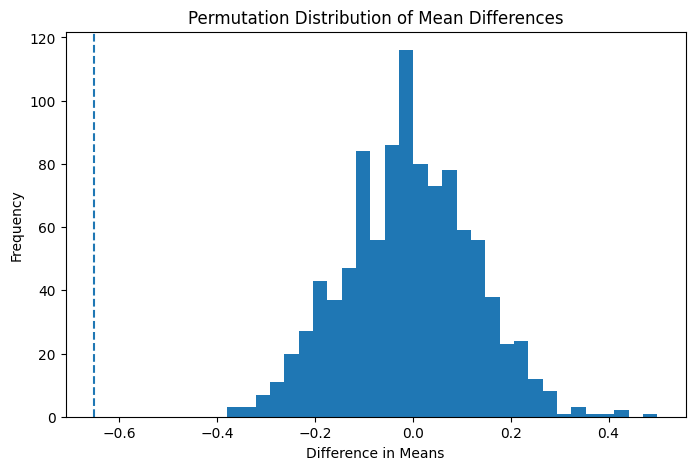

In [25]:
plt.figure(figsize=(8,5))

plt.hist(permutation_differences, bins=30)
plt.axvline(observed_difference, linestyle="dashed")

plt.title("Permutation Distribution of Mean Differences")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")

plt.show()

## Task 7 --- p-value


In [28]:
count = np.sum(np.array(permutation_differences) <= observed_difference)

p_value = count / len(permutation_differences)

print("P-value:", p_value)

P-value: 0.0


In [30]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


Interpretration: Since the p-value is less than 0.05, we reject the null hypothesis. This suggests that there is a statistically significant difference in mean sepal length between Versicolor and Virginica.

**Questions**


What is the null hypothesis (H0) in this specific test?
The null hypothesis states that there is no true difference in mean sepal length between the Versicolor and Virginica species.

What does the permutation distribution represent in terms of random chance?
The permutation distribution represents the differences in means that could occur by random chance if there were actually no real difference between the two species.

Based on your p-value, do you reject or fail to reject the null hypothesis?
Since the p-value is less than 0.05, we reject the null hypothesis. This suggests that there is a statistically significant difference in mean sepal length between Versicolor and Virginica.